# Exercise: Build decision tree model to predict survival based on certain parameters
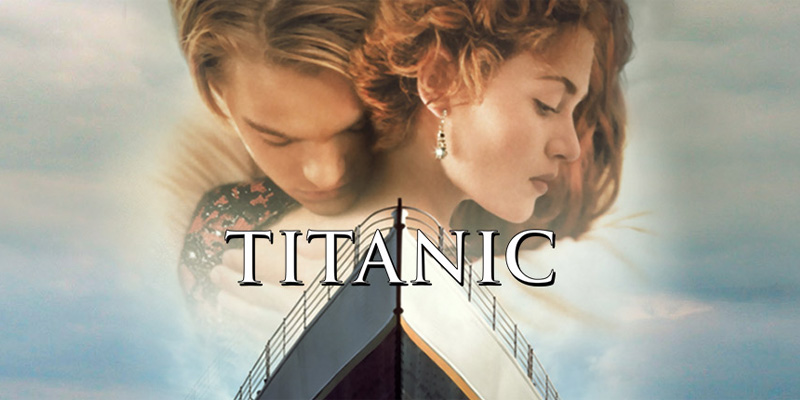

CSV file is available to download at https://github.com/codebasics/py/blob/master/ML/9_decision_tree/Exercise/titanic.csv

**In this file using following columns build a model to predict if person would survive or not,**<br>
1. Pclass
2. Sex
3. Age
4. Fare
__Calculate score of your model__

In [1]:
import pandas as pd
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.shape

(891, 12)

#### Create input and target variables 

In [3]:
# df.drop(['PassengerId','Survived','Name','SibSp','Parch','Ticket','Cabin','Embarked'],axis='columns',inplace=True) 

# if "inplace=True" is used then, assignment will not work, so please do not use it

In [4]:
# inputs = df[['Pclass', 'Sex', 'Age', 'Fare']]
inputs = df.drop(['PassengerId','Survived','Name','SibSp','Parch','Ticket','Cabin','Embarked'],axis='columns')
inputs.head()

,Pclass,Sex,Age,Fare
0,3,male,22.0,7.2500
1,1,female,38.0,71.2833
2,3,female,26.0,7.9250
3,1,female,35.0,53.1000
4,3,male,35.0,8.0500


In [5]:
target = df['Survived']
target.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

#### check for any NaN in Pandas DataFrame: 

In [6]:
df.isnull().values.any()

True

In [7]:
df['Pclass'].isnull().values.any()

False

In [8]:
df['Sex'].isnull().values.any()

False

In [9]:
df['Fare'].isnull().values.any()

False

In [10]:
df['Age'].isnull().values.any()

True

####  Count the NaN under a single DataFrame column:

In [11]:
df['Age'].isnull().sum()

177

#### fills the NaN of feature 'Age' with mean value 

In [12]:
inputs.Age = inputs.Age.fillna(inputs.Age.mean())
inputs.Age.mean()
# inputs.Age

29.699117647058763

In [13]:
inputs.head()

,Pclass,Sex,Age,Fare
0,3,male,22.0,7.2500
1,1,female,38.0,71.2833
2,3,female,26.0,7.9250
3,1,female,35.0,53.1000
4,3,male,35.0,8.0500


#### Create label encoder for the string variables, since ML do not recognise string. OneHotEncode is not suitable here for decision tree

In [14]:
from sklearn.preprocessing import LabelEncoder
le_sex = LabelEncoder()

#### Fit and transformer the features (independent variable)

In [15]:
# this will automatically add the new column in the same matrix

inputs['n_sex'] = le_sex.fit_transform(inputs['Sex'])

#### Get to know encoded values assigned by Label encoding

In [16]:
print(le_sex.classes_) # it begins from zerob

['female' 'male']


#### Drop all the previous columns, which are remained

In [17]:
inputs_n = inputs.drop(['Sex'], axis='columns')
inputs_n.head()

,Pclass,Age,Fare,n_sex
0,3,22.0,7.2500,1
1,1,38.0,71.2833,0
2,3,26.0,7.9250,0
3,1,35.0,53.1000,0
4,3,35.0,8.0500,1


### Use tree for decision

In [18]:
from sklearn import tree
model = tree.DecisionTreeClassifier()

#### Train the decision tree

In [19]:
model.fit(inputs_n, target)

DecisionTreeClassifier()

### To get the score of model, we need sklearn train_test_split

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train,X_test,y_train,y_test = train_test_split(inputs_n,target,test_size=0.2)
len(X_train)

712

In [22]:
len(X_test)

179

In [23]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [24]:
model.score(X_test,y_test)

0.7653631284916201